# 01 — Eclipse geometry

Computes the Sun and Moon positions for the 12 August 2026 partial solar eclipse in Antwerp.


In [1]:
# Load the analysis modules and define the project output directories.

import matplotlib.pyplot as plt
import pandas as pd
from pvlib import solarposition

from eclipse_viewshed.project import repository_root
PROJECT_ROOT = repository_root()

from eclipse_viewshed import eclipse, solar

FIGURES = PROJECT_ROOT / "reports" / "figures"
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110


## Solar track


In [2]:
# Calculate the Sun's altitude and azimuth throughout the eclipse window.
track = solar.sun_track(start_cest=19.0, end_cest=21.25, step_seconds=30)

track.head()


,utc_hours,cest,altitude_deg,azimuth_deg
0,17.000000,19:00,18.931091,270.322273
1,17.008333,19:00,18.852921,270.419483
2,17.016667,19:01,18.774752,270.516650
3,17.025000,19:02,18.696587,270.613772
4,17.033333,19:02,18.618425,270.710851


## Contact times


In [3]:
# Calculate the eclipse contact times and maximum coverage for Antwerp.
contacts = eclipse.contacts()
CEST = solar.UTC_OFFSET_HOURS

KEY_MOMENTS = {
    "first contact": contacts["first_contact_utc"] + CEST,
    "maximum":       contacts["maximum_utc"] + CEST,
    "last contact":  contacts["last_contact_utc"] + CEST,
}

rows = []
for label, hours in KEY_MOMENTS.items():
    altitude, azimuth = solar.sun_altaz(hours - CEST)
    circ = eclipse.circumstances(hours - CEST)
    rows.append({
        "moment": label,
        "CEST": solar.format_cest(hours),
        "altitude_deg": round(altitude, 2),
        "azimuth_deg": round(azimuth, 2),
        "separation_deg": round(circ.separation_deg, 4),
        "obscuration": round(circ.obscuration, 4),
    })

key = pd.DataFrame(rows)

DURATION_MIN = (contacts["last_contact_utc"] - contacts["first_contact_utc"]) * 60
print(f"eclipse runs {DURATION_MIN:.0f} minutes, "
      f"maximum obscuration {100 * contacts['max_obscuration']:.1f}%")
key


eclipse runs 107 minutes, maximum obscuration 88.8%


,moment,CEST,altitude_deg,azimuth_deg,separation_deg,obscuration
0,first contact,19:18,16.09,273.83,0.5344,0.0000
1,maximum,20:13,7.70,284.22,0.0580,0.8877
2,last contact,21:05,0.39,294.19,0.5342,0.0000


## Validation

Checks the Sun's position against NREL's Solar Position Algorithm and the eclipse contacts against published local circumstances.


In [4]:
# Compare the calculated Sun positions and eclipse circumstances with independent references.
PUBLISHED = {
    "first contact": 19 + 18/60 +  8/3600,
    "maximum":       20 + 12/60 + 58/3600,
    "last contact":  21 +  5/60,
}
TOLERANCE_SECONDS = 15.0

def format_hhmmss(hours):
    total_seconds = round(hours * 3600)
    hh, remainder = divmod(total_seconds, 3600)
    mm, ss = divmod(remainder, 60)
    return f"{hh:02d}:{mm:02d}:{ss:02d}"

checks = {}
for label, published in PUBLISHED.items():
    delta_seconds = abs(KEY_MOMENTS[label] - published) * 3600
    checks[f"{label} within {TOLERANCE_SECONDS:.0f} sec"] = (
        delta_seconds <= TOLERANCE_SECONDS
    )
    print(f"  {label:<14} computed {format_hhmmss(KEY_MOMENTS[label])}"
          f"   published {format_hhmmss(published)}"
          f"   delta {delta_seconds:.1f} sec")

obsc_delta = abs(contacts["max_obscuration"] - 0.892)
checks["obscuration within 1 point"] = obsc_delta <= 0.01
print(f"  {'obscuration':<14} computed {100*contacts['max_obscuration']:.1f}%"
      f"   published 89.2%   delta {100*obsc_delta:.1f} points")

altitude, azimuth = solar.sun_altaz(KEY_MOMENTS["maximum"] - CEST)
checks["maximum inside the wedge"] = solar.WEDGE_AZ_MIN < azimuth < solar.WEDGE_AZ_MAX
checks["sun above horizon at maximum"] = altitude > 0

spa_times = pd.date_range(
    "2026-08-12 17:00:00", "2026-08-12 19:15:00",
    freq="15min", tz="UTC",
)
spa = solarposition.get_solarposition(
    spa_times, solar.ANTWERP_LAT, solar.ANTWERP_LON, method="nrel_numpy",
)
ours = pd.DataFrame(
    [solar.sun_altaz(t.hour + t.minute / 60) for t in spa_times],
    columns=["altitude_deg", "azimuth_deg"], index=spa_times,
)
altitude_delta = (ours["altitude_deg"] - spa["apparent_elevation"]).abs().max()
azimuth_delta = (ours["azimuth_deg"] - spa["azimuth"]).abs().max()
checks["solar altitude agrees with NREL SPA"] = altitude_delta <= 0.01
checks["solar azimuth agrees with NREL SPA"] = azimuth_delta <= 0.01
print(f"  NREL SPA       maximum difference: "
      f"{altitude_delta:.4f}° altitude, {azimuth_delta:.4f}° azimuth")

print()
for label, ok in checks.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {label}")
assert all(checks.values()), "Eclipse circumstances disagree with published values."


  first contact  computed 19:18:11   published 19:18:08   delta 3.0 sec
  maximum        computed 20:12:52   published 20:12:58   delta 6.5 sec
  last contact   computed 21:04:51   published 21:05:00   delta 9.1 sec
  obscuration    computed 88.8%   published 89.2%   delta 0.4 points
  NREL SPA       maximum difference: 0.0023° altitude, 0.0012° azimuth

  [PASS] first contact within 15 sec
  [PASS] maximum within 15 sec
  [PASS] last contact within 15 sec
  [PASS] obscuration within 1 point
  [PASS] maximum inside the wedge
  [PASS] sun above horizon at maximum
  [PASS] solar altitude agrees with NREL SPA
  [PASS] solar azimuth agrees with NREL SPA


## Solar path


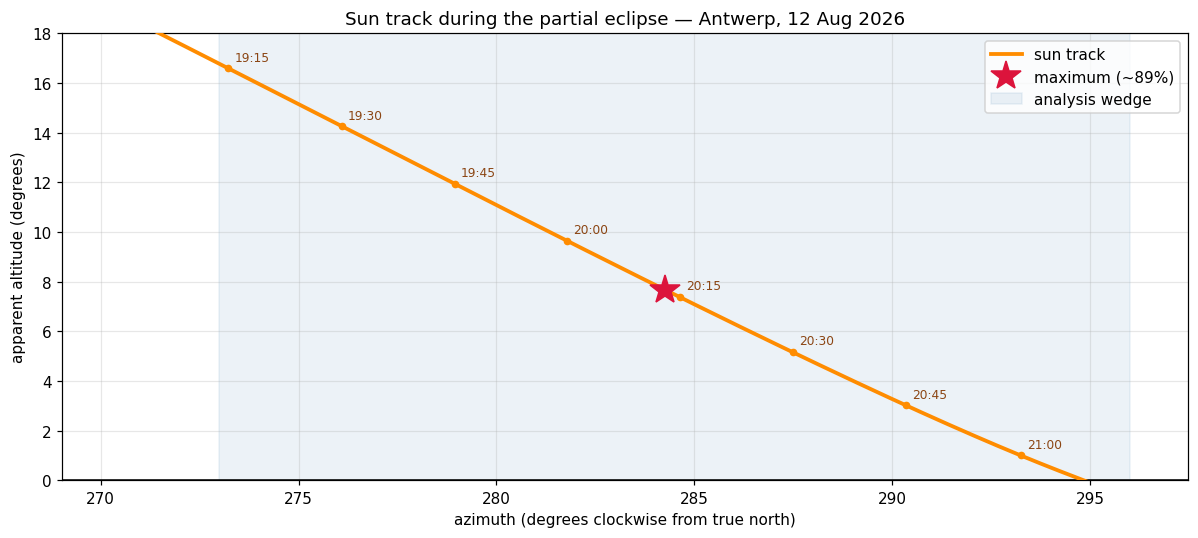

In [5]:
# Plot the Sun's path and mark the key eclipse times.
fig, ax = plt.subplots()

ax.plot(track["azimuth_deg"], track["altitude_deg"],
        color="darkorange", lw=2.5, label="sun track", zorder=3)

# Draw the apparent solar path and mark 15-minute intervals.
for _, row in track.iloc[::30].iterrows():
    ax.plot(row["azimuth_deg"], row["altitude_deg"], "o",
            ms=4, color="darkorange", zorder=4)
    ax.annotate(row["cest"], (row["azimuth_deg"], row["altitude_deg"]),
                xytext=(4, 5), textcoords="offset points", fontsize=8,
                color="saddlebrown")


rmax = solar.at_time(track, KEY_MOMENTS["maximum"])
ax.plot(rmax["azimuth_deg"], rmax["altitude_deg"], "*",
        ms=20, color="crimson", zorder=5, label="maximum (~89%)")


ax.axvspan(solar.WEDGE_AZ_MIN, solar.WEDGE_AZ_MAX,
           color="steelblue", alpha=0.10, label="analysis wedge")

ax.axhline(0, color="k", lw=1)
ax.set_xlabel("azimuth (degrees clockwise from true north)")
ax.set_ylabel("apparent altitude (degrees)")
ax.set_title("Sun track during the partial eclipse — Antwerp, 12 Aug 2026")
ax.set_ylim(0, 18)
ax.grid(alpha=0.3)
ax.legend(loc="upper right")

fig.tight_layout()
fig.savefig(FIGURES / "01_sun_track.png", dpi=150)
plt.show()


## Outputs


In [6]:
# Save the solar track and eclipse circumstances for downstream notebooks.
import json

out = PROCESSED / "sun_track_20260812.csv"
track.to_csv(out, index=False)
print(f"wrote {out.relative_to(PROJECT_ROOT)}  ({len(track)} rows)")

contacts_out = PROCESSED / "01_eclipse_contacts.json"
payload = {
    "first_contact_cest": KEY_MOMENTS["first contact"],
    "maximum_cest":       KEY_MOMENTS["maximum"],
    "last_contact_cest":  KEY_MOMENTS["last contact"],
    "first_contact_hhmm": solar.format_cest(KEY_MOMENTS["first contact"]),
    "maximum_hhmm":       solar.format_cest(KEY_MOMENTS["maximum"]),
    "last_contact_hhmm":  solar.format_cest(KEY_MOMENTS["last contact"]),
    "max_obscuration":    contacts["max_obscuration"],
    "sun_alt_at_max_deg": round(altitude, 2),
    "sun_az_at_max_deg":  round(azimuth, 2),
    "duration_min":       round(DURATION_MIN, 1),
}
contacts_out.write_text(json.dumps(payload, indent=2))
print(f"wrote {contacts_out.relative_to(PROJECT_ROOT)}")
print(json.dumps(payload, indent=2))


wrote data\processed\sun_track_20260812.csv  (271 rows)
wrote data\processed\01_eclipse_contacts.json
{
  "first_contact_cest": 19.30305175781237,
  "maximum_cest": 20.214311326352988,
  "last_contact_cest": 21.080802408853934,
  "first_contact_hhmm": "19:18",
  "maximum_hhmm": "20:13",
  "last_contact_hhmm": "21:05",
  "max_obscuration": 0.887724856952552,
  "sun_alt_at_max_deg": 7.7,
  "sun_az_at_max_deg": 284.22,
  "duration_min": 106.7
}
